In [1107]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import random
from qiskit.quantum_info import random_clifford, random_pauli, entropy, Clifford, negativity
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
import matplotlib.pyplot as plt
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import numpy as np
from qiskit.visualization import plot_histogram
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

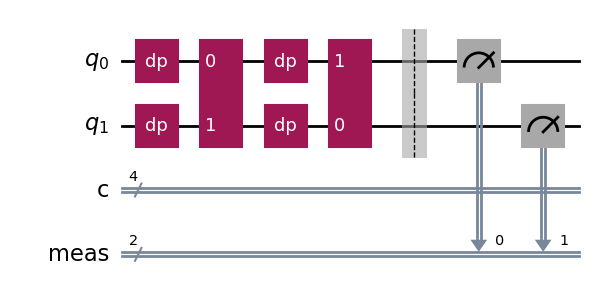

In [1108]:
def random_depolarizing_channel(p, L, t):
    for i in range(L):
            depolarizingchannel = random_clifford(1, seed=None)
            circuit.unitary(depolarizingchannel, [i], label="dp")
        
def random_brickwork_circuit(p, T, L):
    global circuit
    circuit = QuantumCircuit(L, T**2)

    for t in range(T):
        random_depolarizing_channel(p, L, t)
        if t % 2 == 0:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                circuit.unitary(gate, [2*i, 2*i+1], label=" ")
        else:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                if 2*i == L-2:
                    circuit.unitary(gate, [L-1, 0], label=" ")
                else:
                    circuit.unitary(gate, [2*i+1, 2*i+2], label=" ")
    circuit.measure_all()

random_brickwork_circuit(0.1, 2, 2)

circuit.draw("mpl")

In [1109]:
    
# This creates the depolarizing error channel,
# epsilon(P) = (1-P)rho + (P/3)(XrhoX + YrhoY + ZrhoZ).
p = 0
depo_err_chan = depolarizing_error(p, 1)

# Creating the noise model to be used during execution.
noise_model = NoiseModel()
noise_model.add_basis_gates(['unitary'])

noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"]) # measurement error is applied to dp

In [1110]:
print(depo_err_chan)

QuantumError on 1 qubits. Noise circuits:
  P(0) = 1.0, Circuit = 
   ┌───┐
q: ┤ I ├
   └───┘


In [1111]:
print(noise_model)

NoiseModel: Ideal


In [1112]:
sim_noise = AerSimulator(noise_model=noise_model)

passmanager = generate_preset_pass_manager(
    optimization_level=3, backend=sim_noise
)
circ_tnoise = passmanager.run(circuit)

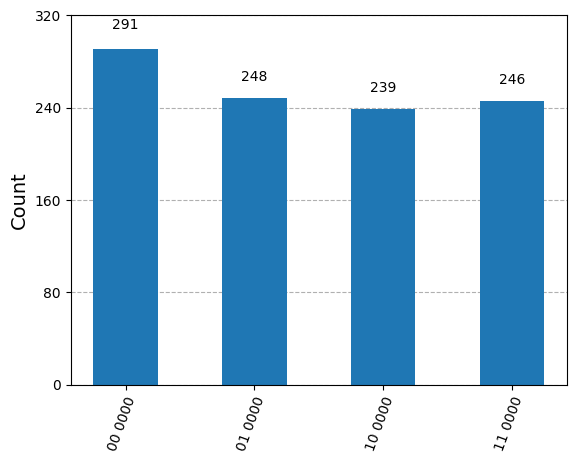

In [1113]:
result = sim_noise.run(circ_tnoise).result()
counts_bit_flip = result.get_counts(0)
 
plot_histogram(counts_bit_flip)

In [ ]:
circuit.remove_final_measurements()
result = Statevector(circuit)

negv = negativity()

TypeError: partial_trace() missing 1 required positional argument: 'qargs'